# Bitcoin Sentiment Analysis


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
fear_greed = pd.read_csv("fear_greed_index.csv")
trades = pd.read_csv("historical_data.csv")

print(fear_greed.head())
print(trades.head())

    timestamp  value classification        date
0  1517463000     30           Fear  2018-02-01
1  1517549400     15   Extreme Fear  2018-02-02
2  1517635800     40           Fear  2018-02-03
3  1517722200     24   Extreme Fear  2018-02-04
4  1517808600     11   Extreme Fear  2018-02-05
                                      Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   

   Size Tokens  Size USD Side     Timestamp IST  Start Position Direction  \
0       986.87   7872.16  BUY  02-12-2024 22:50        0.000000       Buy   
1        16.00    127.68  BUY  02-12-2024 22:50      986.524596       Buy   
2       144.09   1150.63  BUY  02-12-2024 22:50 

/tmp/ipykernel_1145/2302798112.py:2: DtypeWarning: Columns (12) have mixed types. Specify dtype option on import or set low_memory=False.
  trades = pd.read_csv("historical_data.csv")


In [3]:
print(fear_greed.columns)
print(trades.columns)


Index(['timestamp', 'value', 'classification', 'date'], dtype='object')
Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp'],
      dtype='object')


In [5]:
# Check sample timestamps
print(trades['Timestamp IST'].head())

# Convert safely
trades['Timestamp IST'] = pd.to_datetime(
    trades['Timestamp IST'],
    errors='coerce'
)

# Check invalid rows
print(trades['Timestamp IST'].isna().sum())

0    02-12-2024 22:50
1    02-12-2024 22:50
2    02-12-2024 22:50
3    02-12-2024 22:50
4    02-12-2024 22:50
Name: Timestamp IST, dtype: object
54147


In [7]:
print(trades['Timestamp IST'].dtype)

print(trades['Timestamp IST'].head(20))

datetime64[ns]
0    2024-02-12 22:50:00
1    2024-02-12 22:50:00
2    2024-02-12 22:50:00
3    2024-02-12 22:50:00
4    2024-02-12 22:50:00
5    2024-02-12 22:50:00
6    2024-02-12 22:50:00
7    2024-02-12 22:50:00
8    2024-02-12 22:50:00
9    2024-02-12 22:50:00
10   2024-02-12 22:50:00
11   2024-02-12 22:51:00
12   2024-02-12 22:51:00
13   2024-02-12 22:51:00
14   2024-02-12 22:51:00
15   2024-02-12 22:54:00
16   2024-02-12 22:54:00
17   2024-02-12 22:54:00
18   2024-02-12 22:54:00
19   2024-02-12 22:54:00
Name: Timestamp IST, dtype: datetime64[ns]


In [8]:
trades['Timestamp IST'] = pd.to_datetime(
    trades['Timestamp IST'],
    format='%d-%m-%Y %H:%M'
)

In [9]:
trades['date'] = trades['Timestamp IST'].dt.date

fear_greed['date'] = pd.to_datetime(
    fear_greed['date']
).dt.date

merged = pd.merge(
    trades,
    fear_greed,
    on='date',
    how='inner'
)

print("Merged Shape:", merged.shape)

Merged Shape: (17345, 20)


In [10]:
pnl_analysis = merged.groupby(
    'classification'
)['Closed PnL'].mean().sort_values(ascending=False)

print(pnl_analysis)

classification
Extreme Greed    452.808634
Fear             231.194976
Greed             99.221918
Neutral           37.430126
Extreme Fear       8.634040
Name: Closed PnL, dtype: float64


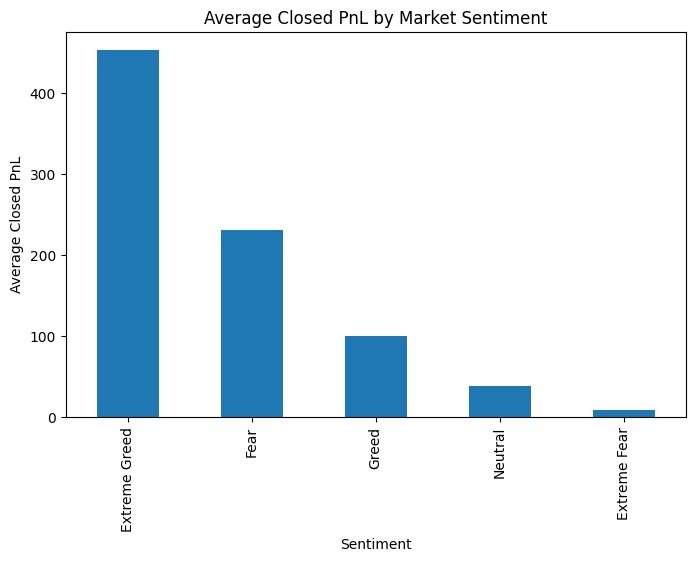

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

pnl_analysis.plot(kind='bar')

plt.title('Average Closed PnL by Market Sentiment')
plt.xlabel('Sentiment')
plt.ylabel('Average Closed PnL')

plt.show()

In [12]:
merged['win'] = merged['Closed PnL'] > 0

win_rate = merged.groupby(
    'classification'
)['win'].mean() * 100

print(win_rate)

classification
Extreme Fear     45.778938
Extreme Greed    46.048273
Fear             41.304009
Greed            48.366215
Neutral          47.888514
Name: win, dtype: float64


In [13]:
volume = merged.groupby(
    'classification'
)['Size USD'].sum()

print(volume)

classification
Extreme Fear      5832032.94
Extreme Greed    12617745.05
Fear             58527831.92
Greed            47894428.47
Neutral           9686766.95
Name: Size USD, dtype: float64
